# 03.3 - Inferential Statistics & Sampling

**Difficulty:** Intermediate
**Priority:** High — foundation of all statistical inference

**Phase:** 03 - Statistics & Probability

**Status:** VERIFIED

---

## 1. What Are We Solving?

We rarely have access to an entire population - we have a **sample**. **Inferential statistics** lets us draw conclusions about the population from a sample, with quantified uncertainty. This unit covers sampling, the Central Limit Theorem, and confidence intervals.

## 2. Why Does This Matter?

In ML, we train on a sample (training data) and want to generalize to the population (all possible data). Understanding sampling and confidence intervals tells us how much to trust our estimates and model performance metrics.

## 3. Prerequisites

- Unit 02.5 (Probability)
- Unit 03.1 (Descriptive statistics)
- Unit 03.2 (Probability distributions)

## 4. Learning Objectives

By the end of this notebook, you should be able to:
- Understand sampling and why it works
- Explain the Central Limit Theorem
- Compute the standard error of the mean
- Construct and interpret confidence intervals
- Understand the relationship between sample size and precision

## 5. Mental Model

A **sample** is a small, random subset of a population. The **sample mean** estimates the **population mean**. The **Central Limit Theorem** says that if we take many samples and compute their means, those means form a Normal distribution centered on the true population mean. The spread of this distribution (the **standard error**) shrinks as sample size grows. A **confidence interval** is a range that likely contains the true population parameter.


## 6. Sampling

**Random sampling** means every member of the population has an equal chance of being selected. This avoids **bias**. Let's simulate sampling from a known population.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# Population: 1 million values with known mean and std
population = np.random.normal(100, 15, size=1000000)
pop_mean = np.mean(population)
pop_std = np.std(population)
print(f"Population: mean={pop_mean:.2f}, std={pop_std:.2f}")

# Take a random sample
sample = np.random.choice(population, size=100, replace=False)
sample_mean = np.mean(sample)
print(f"Sample (n=100): mean={sample_mean:.2f}")
print(f"Sample mean is close to population mean: {abs(sample_mean - pop_mean) < 3}")

# Different samples give slightly different means (sampling variability)
means = [np.mean(np.random.choice(population, size=100, replace=False)) for _ in range(5)]
print(f"\n5 different sample means: {[round(m, 2) for m in means]}")
print("Each sample gives a slightly different estimate - this is sampling variability.")


Population: mean=99.98, std=15.00
Sample (n=100): mean=98.38
Sample mean is close to population mean: True



5 different sample means: [np.float64(99.86), np.float64(101.35), np.float64(99.78), np.float64(101.22), np.float64(102.25)]
Each sample gives a slightly different estimate - this is sampling variability.


## 7. The Central Limit Theorem

The **Central Limit Theorem (CLT)** states: the distribution of sample means approaches a **Normal distribution** as sample size grows, regardless of the population's distribution. The mean of the sample means equals the population mean, and the standard deviation of the sample means (the **standard error**) is `sigma / sqrt(n)`.

Let's demonstrate this with a highly non-Normal population (exponential).


Population (exponential): mean=2.00, skew=2.00


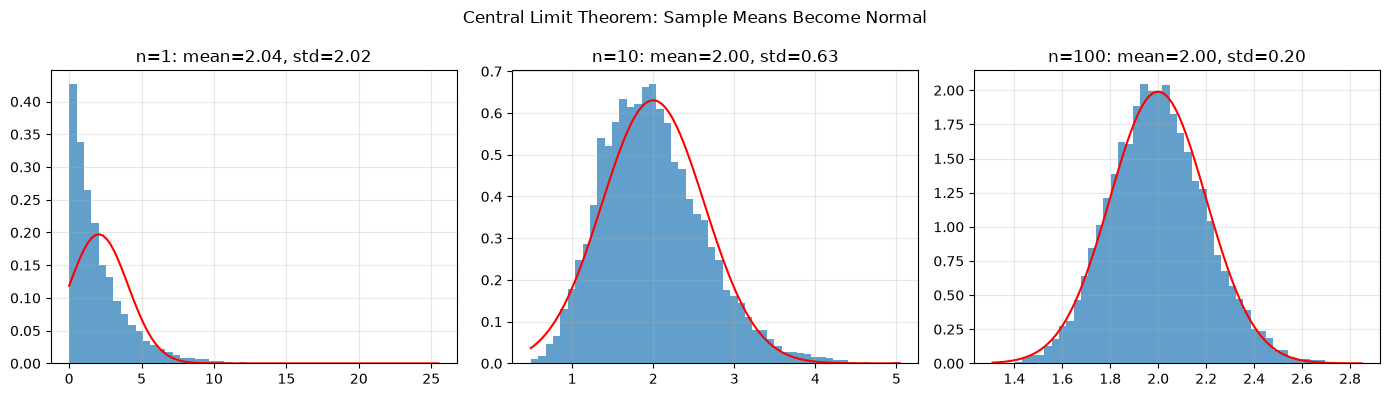

As n grows, the distribution of sample means becomes Normal (red curve).
The spread (std) shrinks as n increases.


In [2]:
# CLT with a non-Normal population (exponential)
np.random.seed(7)
population_exp = np.random.exponential(scale=2, size=1000000)  # right-skewed
print(f"Population (exponential): mean={np.mean(population_exp):.2f}, skew={stats.skew(population_exp):.2f}")

# Take many samples and compute their means
def sample_means(pop, n, n_samples=10000):
    means = []
    for _ in range(n_samples):
        s = np.random.choice(pop, size=n, replace=True)
        means.append(np.mean(s))
    return np.array(means)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, n in zip(axes, [1, 10, 100]):
    means = sample_means(population_exp, n)
    ax.hist(means, bins=50, density=True, alpha=0.7)
    # Overlay normal fit
    x = np.linspace(np.min(means), np.max(means), 100)
    ax.plot(x, stats.norm.pdf(x, np.mean(means), np.std(means)), "r-")
    ax.set_title(f"n={n}: mean={np.mean(means):.2f}, std={np.std(means):.2f}")
    ax.grid(True, alpha=0.3)
plt.suptitle("Central Limit Theorem: Sample Means Become Normal")
plt.tight_layout()
plt.show()

print("As n grows, the distribution of sample means becomes Normal (red curve).")
print("The spread (std) shrinks as n increases.")


## 8. Standard Error of the Mean

The **standard error (SE)** of the mean is the standard deviation of the sample-mean distribution:

`SE = sigma / sqrt(n)`

It measures how precisely the sample mean estimates the population mean. Larger samples -> smaller SE -> more precise estimate.


In [3]:
# Standard error of the mean
pop_std = 15.0

for n in [10, 100, 1000, 10000]:
    se = pop_std / np.sqrt(n)
    print(f"n={n:6d}: SE = {se:.3f}")

print("\nSE decreases as 1/sqrt(n): quadrupling n halves the SE.")

# Verify empirically
np.random.seed(11)
population = np.random.normal(100, 15, 1000000)
for n in [10, 100, 1000]:
    means = sample_means(population, n, n_samples=5000)
    empirical_se = np.std(means)
    theoretical_se = 15 / np.sqrt(n)
    print(f"n={n}: empirical SE={empirical_se:.3f}, theoretical SE={theoretical_se:.3f}")


n=    10: SE = 4.743
n=   100: SE = 1.500
n=  1000: SE = 0.474
n= 10000: SE = 0.150

SE decreases as 1/sqrt(n): quadrupling n halves the SE.


n=10: empirical SE=4.711, theoretical SE=4.743


n=100: empirical SE=1.506, theoretical SE=1.500


n=1000: empirical SE=0.474, theoretical SE=0.474


## 9. Confidence Intervals

A **confidence interval (CI)** gives a range of plausible values for the population parameter. A 95% CI means: if we repeated the sampling many times, 95% of the intervals would contain the true population mean.

For a Normal population, the 95% CI for the mean is:

`sample_mean +/- 1.96 * SE`

(1.96 is the z-score for 95% confidence.)


In [4]:
# Confidence interval for the mean
np.random.seed(13)
population = np.random.normal(100, 15, 1000000)
pop_mean = np.mean(population)

n = 100
sample = np.random.choice(population, size=n, replace=False)
sample_mean = np.mean(sample)
se = np.std(sample, ddof=1) / np.sqrt(n)  # sample std / sqrt(n)

z = 1.96  # 95% confidence
ci_lower = sample_mean - z * se
ci_upper = sample_mean + z * se

print(f"Sample mean: {sample_mean:.2f}")
print(f"Standard error: {se:.2f}")
print(f"95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]")
print(f"True population mean: {pop_mean:.2f}")
print(f"CI contains true mean: {ci_lower <= pop_mean <= ci_upper}")


Sample mean: 99.22
Standard error: 1.52
95% CI: [96.25, 102.19]
True population mean: 99.98
CI contains true mean: True


## 10. Interpreting Confidence Intervals

The key idea: if we repeat the experiment many times, ~95% of the CIs will contain the true mean. Let's verify this empirically.


In [5]:
# Verify: ~95% of 95% CIs contain the true mean
np.random.seed(17)
population = np.random.normal(100, 15, 1000000)
pop_mean = np.mean(population)

n = 50
n_trials = 1000
contains = 0
for _ in range(n_trials):
    sample = np.random.choice(population, size=n, replace=False)
    mean = np.mean(sample)
    se = np.std(sample, ddof=1) / np.sqrt(n)
    if mean - 1.96*se <= pop_mean <= mean + 1.96*se:
        contains += 1

print(f"Out of {n_trials} trials, {contains} CIs contained the true mean.")
print(f"Coverage: {contains/n_trials:.1%} (expected ~95%)")


Out of 1000 trials, 945 CIs contained the true mean.
Coverage: 94.5% (expected ~95%)


## 11. Sample Size and Precision

Larger samples give narrower confidence intervals (more precision). Let's see how the CI width shrinks with sample size.


In [6]:
# CI width vs sample size
np.random.seed(19)
population = np.random.normal(100, 15, 1000000)

for n in [10, 50, 200, 1000]:
    sample = np.random.choice(population, size=n, replace=False)
    mean = np.mean(sample)
    se = np.std(sample, ddof=1) / np.sqrt(n)
    width = 2 * 1.96 * se
    print(f"n={n:5d}: 95% CI width = {width:.2f}")

print("\nLarger samples -> narrower CIs -> more precise estimates.")


n=   10: 95% CI width = 16.42


n=   50: 95% CI width = 8.11
n=  200: 95% CI width = 4.36


n= 1000: 95% CI width = 1.90

Larger samples -> narrower CIs -> more precise estimates.


## 12. Failure Case: Biased Sampling

If the sample is **biased** (not random), the CLT and confidence intervals don't apply - the estimate is systematically wrong. This is a classic failure in surveys and ML data collection.


In [7]:
# Failure: biased sampling
np.random.seed(23)
population = np.random.normal(100, 15, 1000000)
pop_mean = np.mean(population)

# Biased sample: only take values above the mean (e.g. only 'high' responders)
biased_sample = population[population > 100][:100]
biased_mean = np.mean(biased_sample)

print(f"True population mean: {pop_mean:.2f}")
print(f"Biased sample mean:   {biased_mean:.2f}")
print(f"Bias: {biased_mean - pop_mean:.2f}")
print("\nThe biased sample systematically overestimates the mean.")
print("No amount of statistics can fix a biased sample - the data must be random.")


True population mean: 100.02
Biased sample mean:   111.25
Bias: 11.23

The biased sample systematically overestimates the mean.
No amount of statistics can fix a biased sample - the data must be random.


## 13. Debugging: Common Errors

- **Using population std instead of sample std**: use `ddof=1` for sample std.
- **Confusing SE and std**: SE is the std of the sample-mean distribution, not the data.
- **Misinterpreting a 95% CI**: it's not '95% chance the mean is in this interval' - it's about the procedure over many samples.
- **Biased sampling**: if the sample isn't random, inference is invalid.

## 14. Real-World Considerations

- **Train/test split** in ML is a form of sampling - the test set estimates generalization.
- **Cross-validation** gives a distribution of performance estimates, like repeated sampling.
- **Confidence intervals** on model metrics (accuracy, AUC) quantify uncertainty.
- **Bootstrap** resampling estimates uncertainty without parametric assumptions.

## 15. Common Mistakes

- Assuming a small sample is representative.
- Ignoring the standard error when comparing estimates.
- Using the wrong z-score for the confidence level.
- Reporting a point estimate without its uncertainty.

## 16. When NOT to Use

- Don't use Normal-based CIs for very small samples or heavily skewed data - use the t-distribution or bootstrap.
- Don't use inference on biased samples.
- Don't use the CLT when samples are not independent.

## 17. Challenge

Take a sample of size 200 from a population with mean 50 and std 10. Compute the 95% confidence interval for the mean using the sample. Report the interval and whether it contains 50.


## Common Mistakes

| Mistake | Why It's Wrong | Fix |
|---------|---------------|-----|
| "p < 0.05 means the effect is real" | p-value is P(data \| H0), not P(H0 \| data) | Report effect size + CI alongside p-value |
| Using CI for prediction | Confidence interval ≠ prediction interval | Use prediction intervals for individual outcomes |
| Assuming normality without checking | Many tests require Normal assumption | Use Q-Q plots, Shapiro-Wilk, or bootstrap |
| Small sample = reliable estimate | Small n → wide CI → high uncertainty | Report n alongside every estimate |
| Ignoring multiple comparisons | Testing 20 hypotheses at α=0.05 gives ~1 false positive | Use Bonferroni, BH-FDR, or permutation tests |
| Confusing statistical significance with practical significance | Large n can make tiny effects "significant" | Always report effect size (Cohen's d, R²) |

In [8]:
# Challenge: confidence interval from a sample
np.random.seed(29)
population = np.random.normal(50, 10, 1000000)

n = 200
sample = np.random.choice(population, size=n, replace=False)
mean = np.mean(sample)
se = np.std(sample, ddof=1) / np.sqrt(n)
ci = (mean - 1.96*se, mean + 1.96*se)

print(f"Sample mean: {mean:.2f}")
print(f"Standard error: {se:.2f}")
print(f"95% CI: [{ci[0]:.2f}, {ci[1]:.2f}]")
print(f"Contains 50: {ci[0] <= 50 <= ci[1]}")


Sample mean: 49.39
Standard error: 0.66
95% CI: [48.10, 50.69]
Contains 50: True


## Knowledge Check

1. A 95% confidence interval for mean height is [168cm, 172cm]. Does this mean 95% of people are between 168-172cm? What does it actually mean?
2. You flip a coin 100 times and get 55 heads. Using the CLT, construct a 95% CI for the true probability of heads. Does the interval include 0.5?
3. Why does increasing the sample size make confidence intervals narrower? What is the mathematical relationship?
4. You run a hypothesis test and get p = 0.03. Your colleague says "there's a 3% chance the null hypothesis is true." What's wrong with this interpretation?
5. When would you use a bootstrap confidence interval instead of a formula-based one?

## Exit Criteria Checklist

Before moving to the next notebook, verify you can:
- [ ] Explain the difference between a parameter and a statistic
- [ ] Construct a confidence interval for a mean (known and unknown σ)
- [ ] Explain what a p-value is and what it is NOT
- [ ] Apply the CLT to justify normality of sample means
- [ ] Choose between z-test, t-test, and bootstrap based on sample size and assumptions
- [ ] Interpret confidence intervals in practical terms
- [ ] Recognize common misinterpretations of p-values and CIs

## Next Step

In Unit 03.4 (Hypothesis Testing), we will dive deeper into the mechanics of p-values, test statistics, Type I/II errors, power analysis, and how to design experiments that give you reliable answers.

## 18. Closed-Book Recall

Without looking back:

1. What is the Central Limit Theorem?
2. Write the formula for the standard error of the mean.
3. What does a 95% confidence interval mean?
4. How does sample size affect the standard error?
5. Why is random sampling important?

## 19. Teach-Back Questions

Explain to another person:

- Why do sample means form a Normal distribution even for non-Normal data?
- What does a confidence interval actually tell you?
- Why can't statistics fix a biased sample?

## 20. Summary

You now understand inferential statistics: sampling, the Central Limit Theorem, the standard error, and confidence intervals. These tools let you quantify uncertainty and draw conclusions from samples - essential for evaluating ML models.

## 21. Further Experiment

- Implement bootstrap resampling to estimate a confidence interval.
- Compare Normal-based and t-distribution CIs for small samples.
- Compute confidence intervals for model accuracy on a real dataset.

## 22. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: numpy, matplotlib, scipy
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```
